In [15]:
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import datetime as dt

In [32]:
# new filters June 20th
def dataset_filter(dataset):
    # Filtering based on multiple conditions
    condition = (dataset['ACCL:LI21:1:L1S_S_PV'] < 0) & (dataset['ACCL:LI21:1:L1S_S_AV'] > 100) & \
                (dataset['ACCL:LI22:1:ADES'] > 3000) &  (dataset['ACCL:LI22:1:ADES'] < 5400) & \
                (dataset['XRMS on VCC'] > 300) & (dataset['XRMS on VCC'] < 350) & \
                (dataset['YRMS on VCC'] > 250) & (dataset['YRMS on VCC'] < 350) & \
                (dataset['hxr_pulse_intensity'] > 0.02) & (dataset['hxr_pulse_intensity'] < 4.5) & \
                (dataset['HXR electron energy [GeV]'] > 8) & (dataset['HXR photon energy [eV]'] > 7000)
    return dataset[condition]

In [100]:
# get testing samples from dataset
test_set = pd.read_pickle('plotting_data/hxr_archiver_2025-09_cleaned.pkl')
test_set = dataset_filter(test_set)

In [101]:
# Define the fractions of the total number of rows for the selected validation set
selected_ranges = [(0, 1)]

selected_validation_set = pd.DataFrame()
for start_fraction, end_fraction in selected_ranges:
    start_index = int(start_fraction * len(test_set))
    end_index = int(end_fraction * len(test_set))
    subset = test_set.iloc[start_index:end_index]
    selected_validation_set = pd.concat([selected_validation_set, subset])

In [102]:
# Load model
loaded_model_path =  'model/final_lcls_fel_model.pt'
loaded_input_scaler_path = 'model/lcls_fel_input_scaler.pt'
loaded_output_scaler_path = 'model/lcls_fel_output_scaler.pt'

model = torch.load(loaded_model_path, weights_only=False)
input_scaler = torch.load(loaded_input_scaler_path, weights_only=False)
output_scaler = torch.load(loaded_output_scaler_path, weights_only=False)

with open("model/feature_config.yml", "r") as fh:
    yml = yaml.safe_load(fh)
input_cols = list(yml["input_variables"].keys())
output_cols = list(yml["output_variables"].keys())

In [103]:
input_data = torch.tensor(selected_validation_set[input_cols].values)

In [104]:
X_raw = torch.tensor(selected_validation_set[input_cols].values, dtype=torch.float32)
y_raw = torch.tensor(selected_validation_set[output_cols].values, dtype=torch.float32)

In [105]:
# Scale input
X_scaled = input_scaler.transform(X_raw)
y_scaled = output_scaler.transform(y_raw) # SCALED MEASUREMENTS

# Predict
model_output = model(X_scaled)

# Unscale the output
model_output_unscaled = output_scaler.untransform(model_output).detach().numpy() 

# Plot

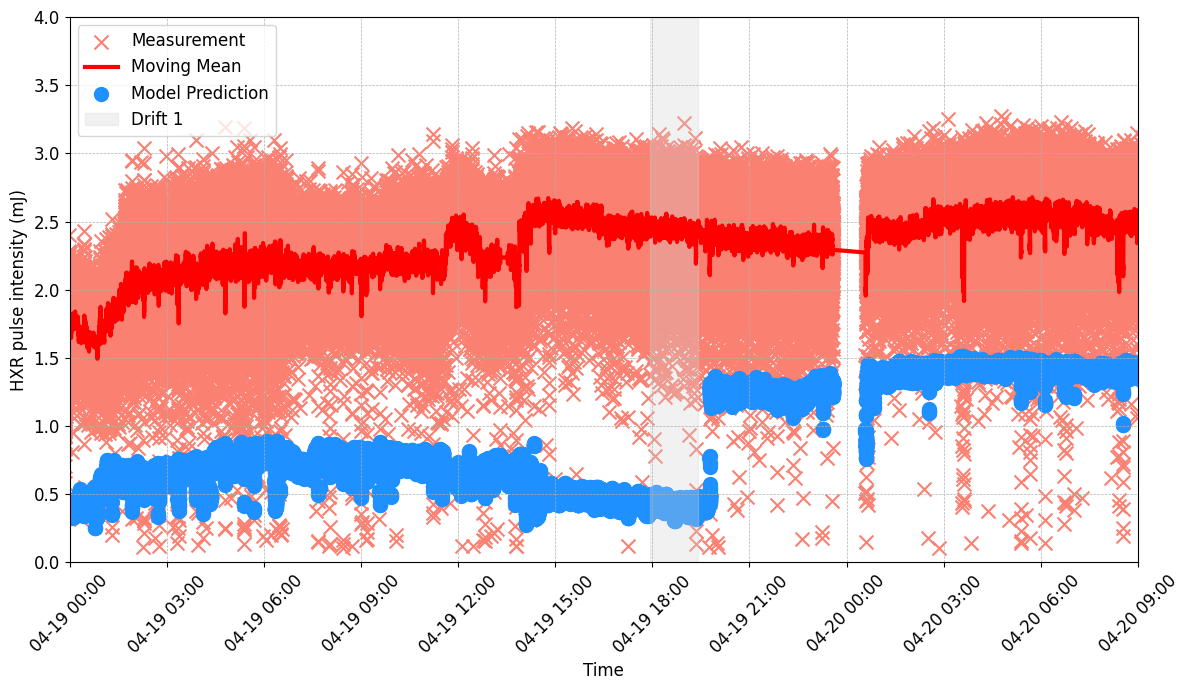

In [64]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

#plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
start_date = pd.Timestamp('2025-04-19 00:00') 
end_date = pd.Timestamp('2025-04-20 09:00')
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-04-19 17:55')
end_shade = pd.Timestamp('2025-04-19 19:24')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 1')

plt.ylim([0, 4])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

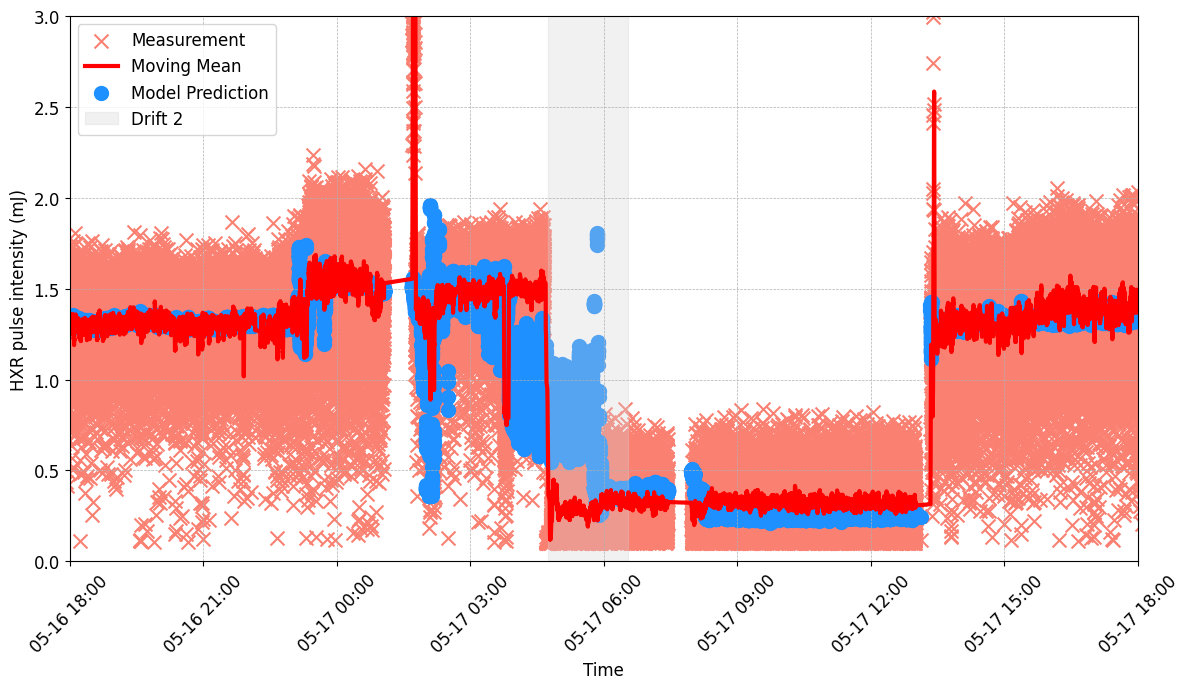

In [71]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

#plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
start_date = pd.Timestamp('2025-05-16 18:00') 
end_date = pd.Timestamp('2025-05-17 18:00')
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-05-17 04:45')
end_shade = pd.Timestamp('2025-05-17 06:33')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 2')

plt.ylim([0, 3])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

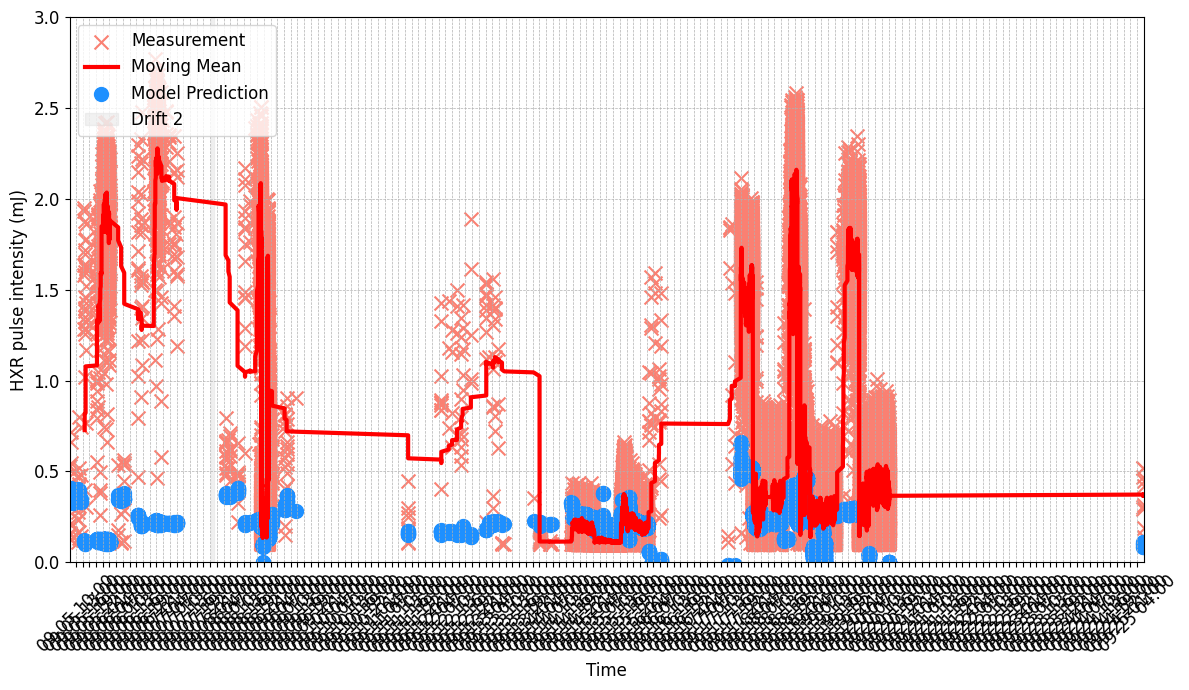

In [81]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
# start_date = pd.Timestamp('2025-09-07 00:00') 
# end_date = pd.Timestamp('2025-09-08 12:00')
# plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-09-07 22:15')
end_shade = pd.Timestamp('2025-09-07 23:35')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 3')

plt.ylim([0, 3])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

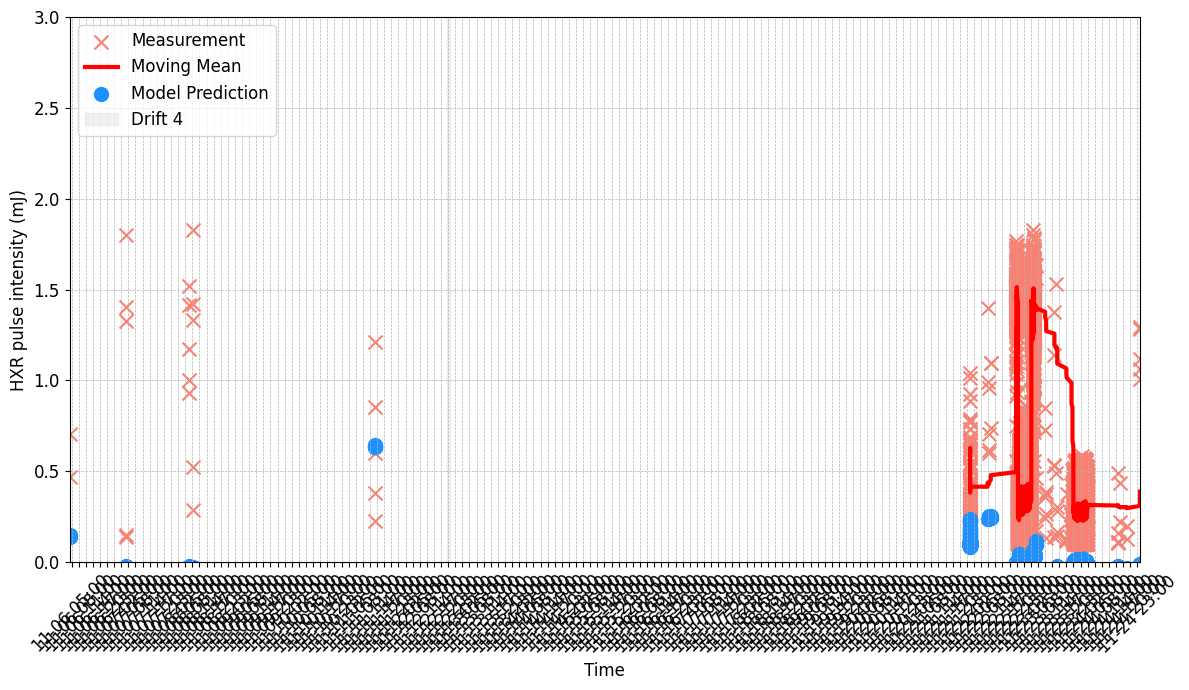

In [89]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
# start_date = pd.Timestamp('2025-11-12 00:00') 
# end_date = pd.Timestamp('2025-11-13 00:00')
# plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-11-12 19:28')
end_shade = pd.Timestamp('2025-11-12 20:50')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 4')

plt.ylim([0, 3])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [25]:
# drift 1 [2025-04-19 17:55:51.153006080-07:00 → 2025-04-19 19:24:11.960220672-07:00]
# drift 2 [2025-05-17 04:44:59.832188416-07:00 → 2025-05-17 06:33:21.784591104-07:00]
# drift 3 [2025-09-07 22:15:48.181196544-07:00 → 2025-09-07 23:35:23.898307072-07:00]
# drift 4 [2025-11-12 19:28:18.762950912-08:00 → 2025-11-12 20:50:03.736012544-08:00]

In [ ]:
# drift 5 [2025-12-08 17:43:05.359381248-08:00 → 2025-12-08 19:12:43.182404608-08:00]


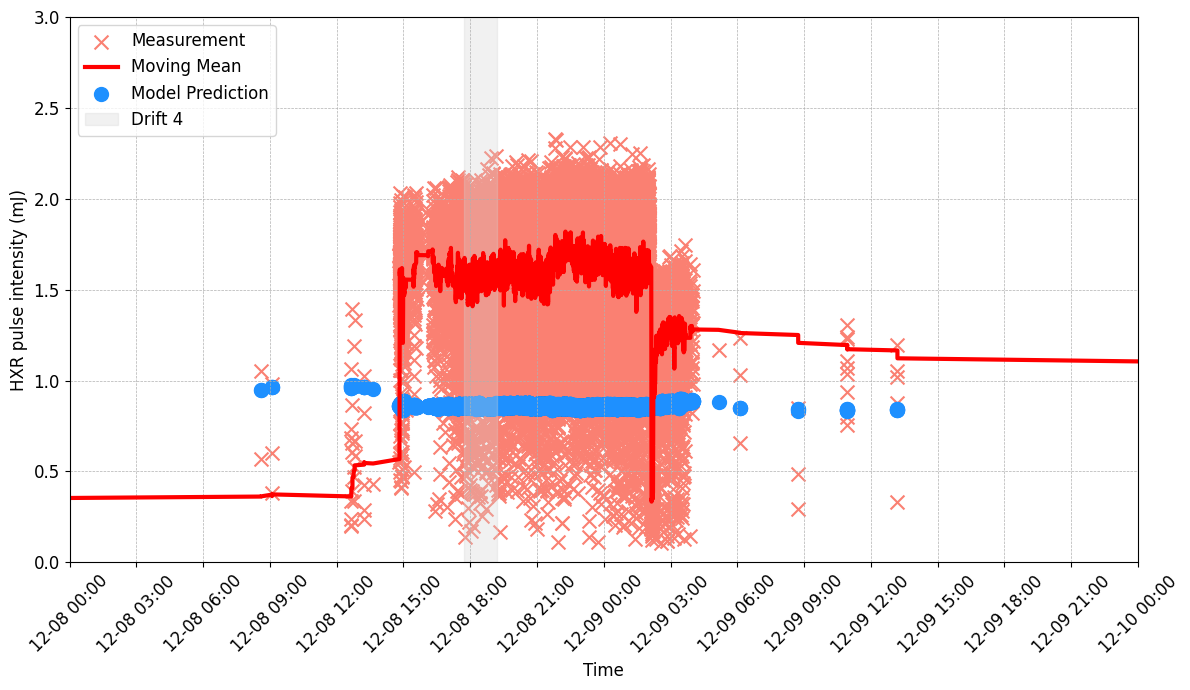

In [99]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
start_date = pd.Timestamp('2025-12-08 00:00') 
end_date = pd.Timestamp('2025-12-10 00:00')
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-12-08 17:43')
end_shade = pd.Timestamp('2025-12-08 19:12')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 4')

plt.ylim([0, 3])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# drift 5 [2025-09-14 10:50:43.958137088-07:00 → 2025-09-14 12:20:07.932805376-07:00] (after wrapping around)

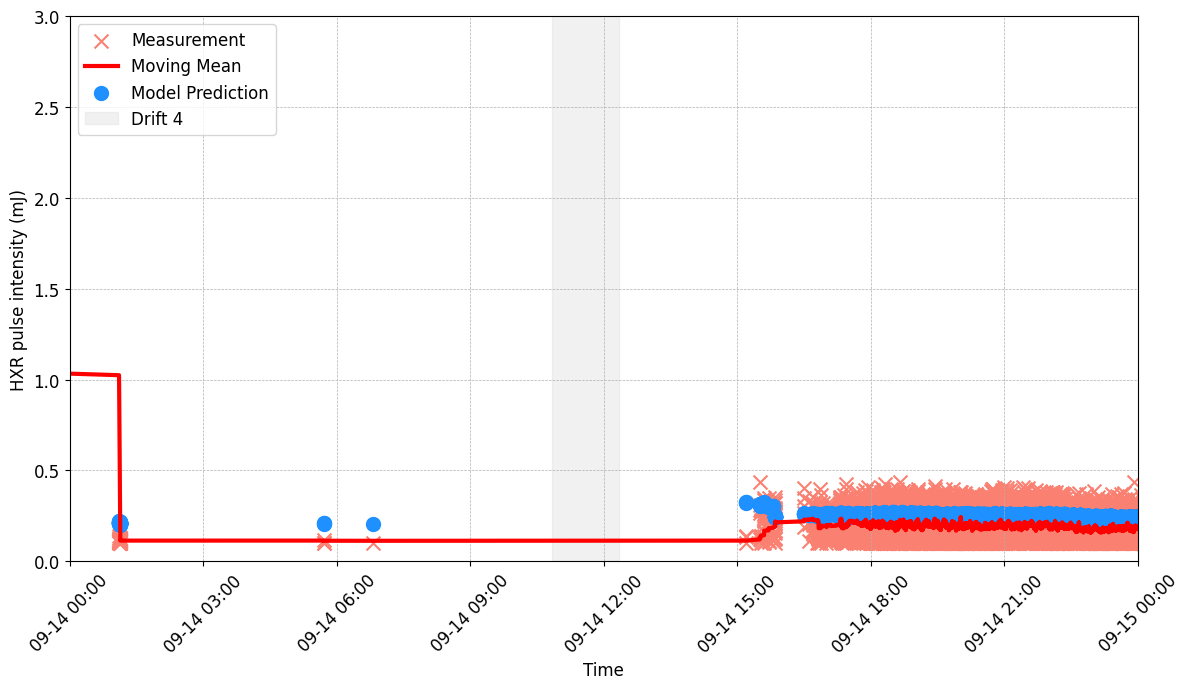

In [106]:
# Plot the unscaled data
date_format = mdates.DateFormatter('%m-%d %H:%M')

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(selected_validation_set.index, ground_truth, label='Measurement', color='salmon', marker='x', s=100)
plt.plot(selected_validation_set.index, moving_avg, label='Moving Mean', color='red', linewidth=3)
plt.scatter(selected_validation_set.index, model_output_unscaled, label='Model Prediction', color='dodgerblue', marker='o', s=100)
plt.xlabel('Time', fontsize=fontsize)
plt.ylabel('HXR pulse intensity (mJ)', fontsize=fontsize)

plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
start_date = pd.Timestamp('2025-09-14 00:00') 
end_date = pd.Timestamp('2025-09-15 00:00')
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

#ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
start_shade = pd.Timestamp('2025-09-14 10:50')
end_shade = pd.Timestamp('2025-09-14 12:20')
plt.fill_betweenx(y=[0, 4], x1=start_shade, x2=end_shade, color='lightgray', alpha=0.3, label='Drift 4')

plt.ylim([0, 3])
plt.legend(fontsize=12, loc='upper left')
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()